In [2]:
# Import libraries
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime, timedelta

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

# Initialize BigQuery client
client = bigquery.Client(project='abridge-client-prod')
print(f"Connected to project: {client.project}")

print("Libraries imported successfully!")


/Users/maggie/projects/abridge-personal-analysis/venv312/lib/python3.12/site-packages/google/auth/_default.py:108: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


Connected to project: abridge-client-prod
Libraries imported successfully!


In [6]:
query0= '''select 
  date(note_generated_date) as note_gen_date,
  feedback_tag, 
  count(distinct encounter_id) as num_enc
FROM `abridge-client-prod.dbt_prod.tblEncounter` ,
UNNEST(feedback_tags) AS feedback_tag
where feedback_tags is not null
group by 1, 2'''
feedback_df = client.query(query0).to_dataframe()

df = feedback_df.copy()


/Users/maggie/projects/abridge-personal-analysis/venv312/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


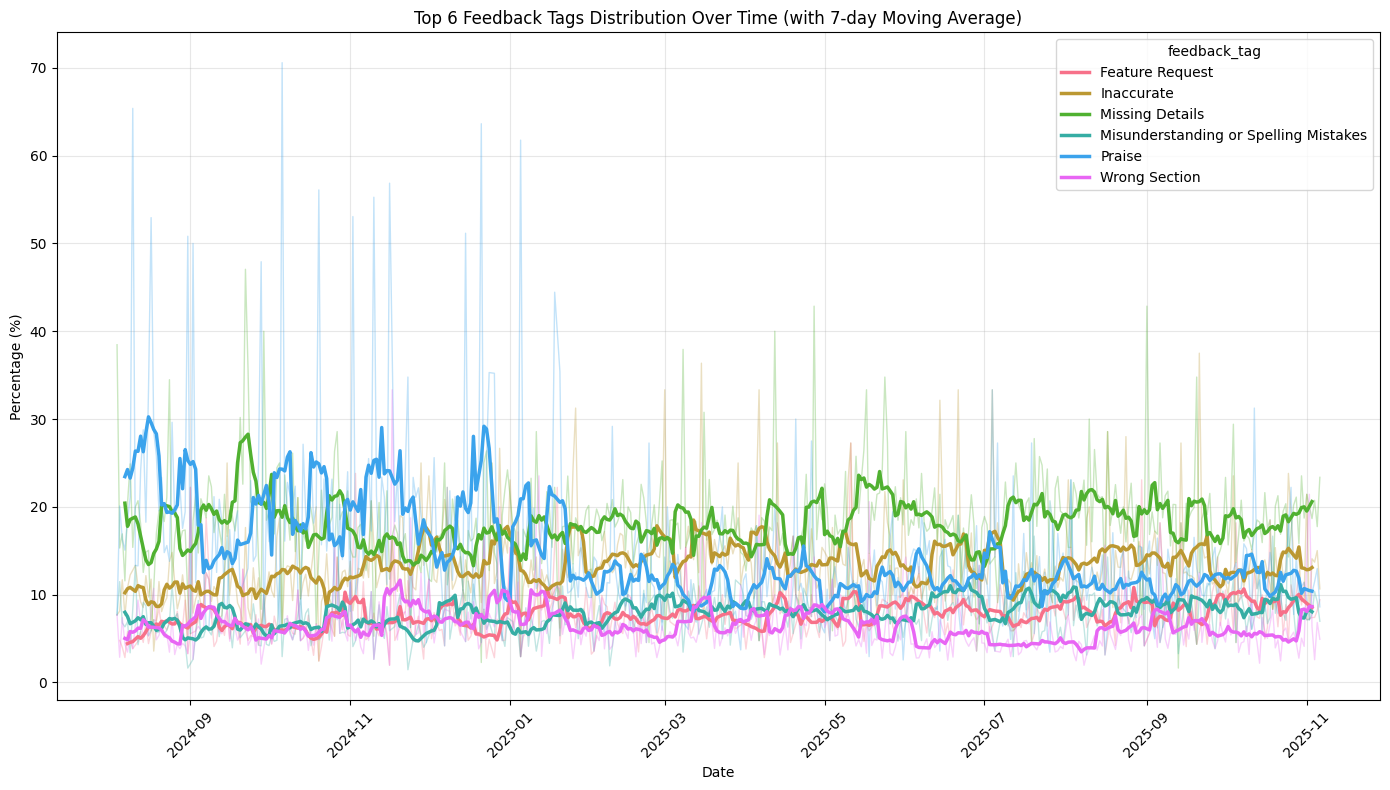

In [35]:
# Get top 6 tags and filter data
top_tags = merged.groupby('feedback_tag')['num_enc'].sum().nlargest(6).index
top_merged = merged[merged['feedback_tag'].isin(top_tags)].copy()

# Convert date to datetime for proper sorting
top_merged['note_gen_date'] = pd.to_datetime(top_merged['note_gen_date'])

# Sort by tag and date, then calculate 7-day moving average using groupby
top_merged = top_merged.sort_values(['feedback_tag', 'note_gen_date'])
top_merged['perc_enc_7ma'] = top_merged.groupby('feedback_tag')['perc_enc'].transform(
    lambda x: x.rolling(window=7, center=True).mean()
)

# Plot with seaborn
plt.figure(figsize=(14, 8))

# Original data (lighter lines)
sns.lineplot(data=top_merged, x='note_gen_date', y='perc_enc', 
             hue='feedback_tag', alpha=0.3, linewidth=1, legend=False)

# 7-day moving average (bold lines)
sns.lineplot(data=top_merged, x='note_gen_date', y='perc_enc_7ma', 
             hue='feedback_tag', linewidth=2.5)

plt.xlabel('Date')
plt.ylabel('Percentage (%)')  
plt.title('Top 6 Feedback Tags Distribution Over Time (with 7-day Moving Average)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
merged.head()

,note_gen_date,feedback_tag,num_enc,total_enc,perc_enc
0,2024-08-04,Grammar Issues,1,13,7.692308
1,2024-08-04,Gratuitous or Irrelevant Information,1,13,7.692308
2,2024-08-04,Inaccurate,1,13,7.692308
3,2024-08-04,Misattribution of Subject,1,13,7.692308
4,2024-08-04,Missing Details,5,13,38.461538


In [9]:
# look at distribution of tags/encounter 
query0= '''select 
  encounter_id,
  count(feedback_tag) as num_fts
FROM `abridge-client-prod.dbt_prod.tblEncounter` ,
UNNEST(feedback_tags) AS feedback_tag
group by 1'''
ft_df = client.query(query0).to_dataframe()




/Users/maggie/projects/abridge-personal-analysis/venv312/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


                           encounter_id  num_fts
0  2e3d5445-422f-4328-a2ef-8938107161e3        5
1  70605079-e05a-46a9-b622-5d3a0ce77a6b        6


<Figure size 1200x800 with 0 Axes>

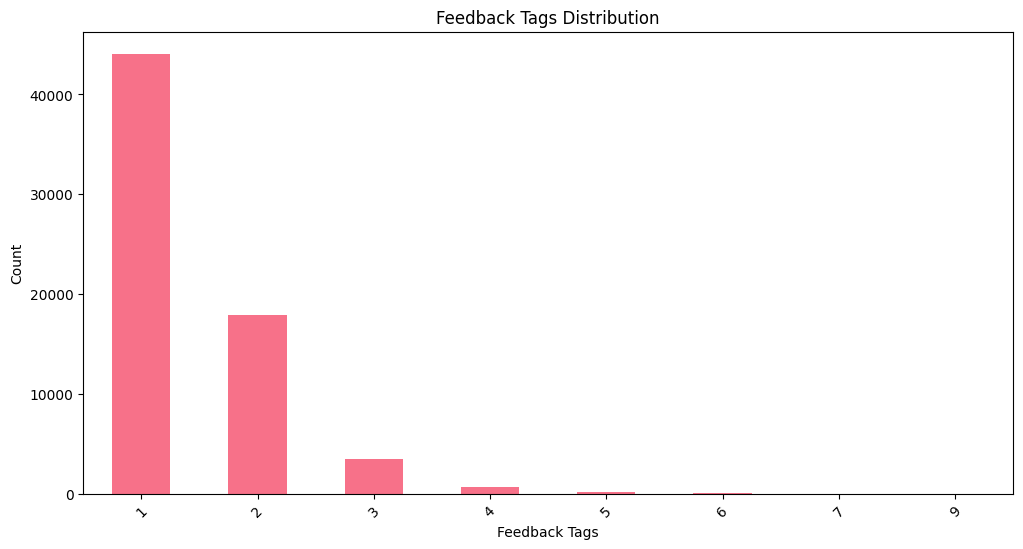

num_fts
1    66.504723
2    27.027068
3     5.170645
4     1.000332
5      0.25046
6     0.042246
7     0.003018
9     0.001509
Name: proportion, dtype: Float64


In [25]:
print(ft_df.head(2))
# Basic histogram/bar chart of feedback tags
plt.figure(figsize=(12, 8))

# Count the frequency of each feedback tag
tag_counts = ft_df['num_fts'].value_counts()

plt.figure(figsize=(12, 6))
ft_df['num_fts'].value_counts().plot(kind='bar')
plt.title('Feedback Tags Distribution')
plt.xlabel('Feedback Tags')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

print(ft_df['num_fts'].value_counts(normalize=True) * 100)

## get metadata for encounters

In [ ]:
# look at distribution of tags/encounter 
query0= '''select 
  encounter_id,
  encounter_surface,
  care_setting,
  orgs,
  count(feedback_tag) as num_fts
FROM `abridge-client-prod.dbt_prod.tblEncounter` ,
UNNEST(feedback_tags) AS feedback_tag
group by 1'''
ft_df = client.query(query0).to_dataframe()




num_fts
1    66.504723
2    27.027068
3     5.170645
4     1.000332
5      0.25046
6     0.042246
7     0.003018
9     0.001509
Name: proportion, dtype: Float64

In [ ]:
query_ft_meta = '''select 
  encounter_id,
  encounter_surface,
  care_setting,
  org,
  specialty_note_type,
  appointment_type,
  hpi_style,
  pbap_style,
  pbap_model,
  hpi_model, 
  hpi_format,
  count(distinct ft)  as num_ft
FROM `abridge-client-prod.dbt_prod.tblEncounter`,
UNNEST(feedback_tags) AS ft
where date(note_generated_date) >= '2025-09-01'
group by 1,2,3,4,5,6,7,8,9,10,11'''
ft_meta_df = client.query(query_ft_meta).to_dataframe()
ft_meta_df.head()


/Users/maggie/projects/abridge-personal-analysis/venv312/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,encounter_id,encounter_surface,care_setting,org,specialty_note_type,appointment_type,hpi_style,pbap_style,pbap_model,hpi_model,hpi_format,num_ft
0,85a29384-8290-4927-b27a-fed09b5a7502,integrated,outpatient,duly-health-and-care,behavioral_health_visit,epic-getProviderAppointments,concise,concise,cs-v2-pbap_concise_bullets_vp_5-2.36.0-section...,cs-v2-hpi_comprehensive_bh_2-2.36.0,bullet,3
1,e389ee54-6e44-4bd3-942b-4488a954886e,inside,outpatient,methodist-dallas,None,epic-haiku,comprehensive,comprehensive,cs-v2-pbap_comprehensive_bullets_vp_5-2.44.0-s...,cs-v2-hpi_comprehensive_14-2.44.0-section_post...,paragraph,1
2,5a48d433-eaca-457f-8b48-dc88a0d4a3dc,integrated,outpatient,bassett,None,epic-getProviderAppointments,comprehensive,comprehensive,cs-v2-pbap_comprehensive_bullets_vp_5-2.35.0-s...,cs-v2-hpi_comprehensive_14-2.35.0-section_post...,paragraph,1
3,f0e251e9-16df-435f-b1f1-e32ce0066c4c,copy-paste,None,west-michigan-family-medicine,None,None,concise,concise,cs-v2-pbap_concise_bullets_vp_5-2.34.0-section...,cs-v2-hpi_concise_14-2.34.0,paragraph,1
4,47ee3115-c1e4-449a-9076-037acac9786c,copy-paste,None,cottage-health,None,None,comprehensive,concise,cs-v2-pbap_concise_bullets_vp_6-3.1.1-section_...,cs-v2-hpi_comprehensive_14-3.1.1-section_postp...,paragraph,1


In [44]:
query_ft = '''select ft
  FROM `abridge-client-prod.dbt_prod.tblEncounter`,
        UNNEST(feedback_tags) AS ft
    group by 1
    '''
ft = client.query(query_ft).to_dataframe()
ft

/Users/maggie/projects/abridge-personal-analysis/venv312/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,ft
0,Inaccurate
1,Wrong Focus
2,Recording Issues
3,EHR Integration Issues
4,None
5,Software Issues
6,Gratuitous or Irrelevant Information
7,User Error
8,Misattribution of Subject
9,Repetitive Information


In [45]:
query_ft_cnt = '''select count(distinct ft) as num_ft
  FROM `abridge-client-prod.dbt_prod.tblEncounter`,
        UNNEST(feedback_tags) AS ft
    '''
count_ft = client.query(query_ft_cnt).to_dataframe()
count_ft

/Users/maggie/projects/abridge-personal-analysis/venv312/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,num_ft
0,25


In [53]:
import pandas as pd
import numpy as np
from io import StringIO

# 1. DEFINE SEVERITY WEIGHTS (Based on the complete list of 25 tags)
# Scale: 10 (Critical Defect) to 0 (Non-Defect/Praise).
SEVERITY_WEIGHTS = {
    'ft0Inaccurate': 10,                 # Critical: Patient safety, billing risk
    'Wrong Focus': 8,                    # High: Misses core medical issue
    'Recording Issues': 6,               # Medium: Potential data loss/misinterpretation
    'EHR Integration Issues': 7,         # Medium-High: Workflow disruption
    'None': 0,                           # Non-Defect
    'Software Issues': 9,                # High: Unacceptable system error
    'Gratuitous or Irrelevant Information': 2, # Low: Note clutter
    'User Error': 6,                     # Medium: Error introduced by user input
    'Misattribution of Subject': 9,      # Critical: Wrong information assigned to patient/provider
    'Repetitive Information': 5,         # Medium: Clutter, but not dangerous
    'Structure and Organization Issues': 5,# Medium: Readability/usability impact
    'Misunderstanding or Spelling Mistakes': 3, # Low: Minor clarity issue
    'Feature Request': 0,                # Non-Defect
    'Missing Section': 9,                # Critical: Major documentation gap
    'Note Not Generated': 10,            # Critical: Total service failure
    'Wording, Style or Terminology Issues': 4, # Low: Professionalism/minor clarity
    'Edits Required: Reasons Unspecified': 5, # Medium: Defect confirmed, but unclear severity
    'Formatting Issues': 3,              # Low: Aesthetic/minor readability
    'Praise': 0,                         # Non-Defect
    'Slow Note Generation': 1,           # Low: UX/efficiency issue, but output is correct
    'Pronoun or Person Issues': 4,       # Low-Medium: Clarity/potential misidentification risk
    'Wrong Section': 5,                  # Medium: Data is present but misplaced
    'Grammar Issues': 2,                 # Low: Minor clarity/professionalism issue
    'Transcription Language Error': 4,   # Low-Medium: Clarity/potential meaning change
    'Missing Details': 8                 # High: Significant data gap impacting care
}

def calculate_debiased_quality_scores(df: pd.DataFrame, debias_factors: list) -> pd.DataFrame:
    """
    Calculates the Note Quality Score (0-100) and then de-biases the doctor's 
    average score using a Contextual Z-Score based on the provided factors.
    """
    
    
    # --- DATA PREPROCESSING & QUARTILE BINNING ---
    
    # Convert duration columns to numeric and handle missing/invalid data
    df['ml_pipeline_duration'] = pd.to_numeric(df['ml_pipeline_duration'], errors='coerce')
    df['audio_duration'] = pd.to_numeric(df['audio_duration'], errors='coerce')
    df.dropna(subset=['ml_pipeline_duration', 'audio_duration'], inplace=True)
    
    # Create Quartile Bins for continuous variables
    # qcut ensures equal number of data points in each bin
    df['ml_pipeline_quartile'] = pd.qcut(
        df['ml_pipeline_duration'], q=4, labels=['ML_Q1', 'ML_Q2', 'ML_Q3', 'ML_Q4'], duplicates='drop'
    ).astype(str)
    df['audio_quartile'] = pd.qcut(
        df['audio_duration'], q=4, labels=['Audio_Q1', 'Audio_Q2', 'Audio_Q3', 'Audio_Q4'], duplicates='drop'
    ).astype(str)
    
    # --- STEP 1: CALCULATE RAW NOTE QUALITY SCORE (WDS) ---

    # Clean up tags and assign weights
    df['feedback_tag'] = df['feedback_tag'].str.strip()
    df['severity_weight'] = df['feedback_tag'].apply(
        lambda x: SEVERITY_WEIGHTS.get(x, 0)
    )

    # Define all grouping keys needed for the note_scores DataFrame
    groupby_keys = ['unique_id', 'encounter_id', 'care_setting', 'hpi_style', 'pbap_style', 'appointment_type', 'ml_pipeline_quartile', 'audio_quartile']
    
    # Calculate D_note (Total Defect Score per Note)
    note_scores = df.groupby(groupby_keys).agg(
        D_note=('severity_weight', 'sum')
    ).reset_index()

    # Calculate D_max (Maximum Possible Defect Score)
    D_max = sum(w for w in SEVERITY_WEIGHTS.values() if w > 0)
    if D_max == 0: D_max = 1 

    # Calculate Q_note (Note Quality Score 0-100)
    note_scores['Note_Quality_Score'] = (
        100 * (1 - (note_scores['D_note'] / D_max))
    ).clip(lower=0, upper=100)
    
    # --- STEP 2: ADDRESS VOLUME BIAS (Doctor Average) ---
    doctor_avg_scores = note_scores.groupby('unique_id')['Note_Quality_Score'].mean().reset_index()
    doctor_avg_scores.rename(columns={'Note_Quality_Score': 'Doctor_Avg_Quality_Score'}, inplace=True)
    
    # Merge the doctor average back
    note_scores = pd.merge(note_scores, doctor_avg_scores, on='unique_id', how='left')

    # --- STEP 3: ADDRESS CONTEXTUAL BIAS (Z-Score Normalization) ---

    final_df = note_scores.copy()
    
    if not debias_factors:
        # If no factors are provided, fall back to global comparison
        final_df['Context'] = 'Global'
        final_df['Contextual_Z_Score'] = 0 
        final_df['Context_Avg_Score'] = final_df['Doctor_Avg_Quality_Score'].mean()
        final_df['Context_Std_Dev'] = final_df['Doctor_Avg_Quality_Score'].std()
    else:
        # Define dynamic context based on user-selected factors
        final_df['Context'] = final_df[debias_factors].astype(str).agg(' | '.join, axis=1)

        # Group the average scores by Context (Peer Group Metrics)
        context_metrics = final_df.groupby('Context')['Doctor_Avg_Quality_Score'].agg(
            Context_Avg_Score='mean',
            Context_Std_Dev='std'
        ).reset_index()
        
        # Fill NaN std_dev (groups of 1 or groups with identical scores) with global standard deviation 
        global_std_dev = final_df['Doctor_Avg_Quality_Score'].std()
        context_metrics['Context_Std_Dev'] = context_metrics['Context_Std_Dev'].fillna(global_std_dev if global_std_dev > 0.1 else 0.1)

        # Merge context metrics back to calculate the Z-Score
        final_df = pd.merge(final_df, context_metrics, on='Context', how='left')

        # Calculate Contextual Z-Score (De-biased Metric)
        # Z-Score = (Doctor's Average - Peer Group Average) / Peer Group Standard Deviation
        final_df['Contextual_Z_Score'] = (
            final_df['Doctor_Avg_Quality_Score'] - final_df['Context_Avg_Score']
        ) / final_df['Context_Std_Dev']
    
    # Select and return the key metrics
    return final_df[[
        'unique_id', 
        'encounter_id',
        'care_setting',
        'hpi_style',
        'pbap_style',
        'appointment_type',
        'ml_pipeline_quartile',
        'audio_quartile',
        'Context', 
        'D_note', 
        'Note_Quality_Score', 
        'Doctor_Avg_Quality_Score', 
        'Contextual_Z_Score'
    ]].sort_values(['Contextual_Z_Score', 'Note_Quality_Score'], ascending=[False, False]).drop_duplicates(subset=['unique_id', 'encounter_id'])

In [51]:
DEBIAS_FACTORS_1 = ['care_setting', 'hpi_style']
query = '''select * from dbt_mchen.tbl_qs_from_tags 
'''
input_df = client.query(query).to_dataframe()



/Users/maggie/projects/abridge-personal-analysis/venv312/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [ ]:
quality_scores_df = calculate_debiased_quality_scores(input_df, DEBIAS_FACTORS_1)


In [58]:
quality_scores_df.sort_values('Note_Quality_Score', ascending=False).head(100)

,unique_id,encounter_id,care_setting,hpi_style,pbap_style,appointment_type,ml_pipeline_quartile,audio_quartile,Context,D_note,Note_Quality_Score,Doctor_Avg_Quality_Score,Contextual_Z_Score
45,abridge_7x7S6KG1eUVUNL0jGUAC89LVyL22,2b799b6d-cc6d-4849-aea5-8671dc74f7f3,outpatient,comprehensive,concise,athena-scheduling,ML_Q3,Audio_Q4,outpatient | comprehensive,0,100.0,100.000000,2.497533
15469,fhir_ser_eLHnUGFYGD9jPps-9MG5PoSeIBvj0h2lPL8.Q...,fbf7304f-2d61-4fb9-806a-94fe52f33c15,outpatient,comprehensive,comprehensive,epic-getProviderAppointments,ML_Q1,Audio_Q1,outpatient | comprehensive,0,100.0,96.400000,0.604334
22764,fhir_ser_eT7457c95So5Vw8oIAmVGrmfbu0GYaOiL8Yq3...,6e254d3b-07fd-42c7-9780-dea632ebc799,outpatient,comprehensive,concise,epic-haiku,ML_Q1,Audio_Q2,outpatient | comprehensive,0,100.0,96.400000,0.604334
23513,fhir_ser_eUITh15eR-tRNU7P07W-B4A3,45096634-1fb4-4fd1-a808-40c0c23db0d9,outpatient,comprehensive,concise,epic-haiku,ML_Q2,Audio_Q2,outpatient | comprehensive,0,100.0,96.400000,0.604334
23516,fhir_ser_eUITh15eR-tRNU7P07W-B4A3,cf5d432b-f74f-4c99-ba5c-107d411d4e42,outpatient,comprehensive,concise,epic-haiku,ML_Q4,Audio_Q3,outpatient | comprehensive,0,100.0,96.400000,0.604334
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7160,fhir_ser_e8K1DvFWkv6QX3Yd4qdVEDw3,f527f112-65c3-41c6-b96f-bdcf7445c339,outpatient,comprehensive,concise,epic-haiku,ML_Q1,Audio_Q3,outpatient | comprehensive,0,100.0,96.400000,0.604334
7161,fhir_ser_e8K1DvFWkv6QX3Yd4qdVEDw3,f8dc09eb-11b5-41f8-ac06-7c934fd59cd9,outpatient,comprehensive,concise,epic-haiku,ML_Q3,Audio_Q3,outpatient | comprehensive,0,100.0,96.400000,0.604334
7162,fhir_ser_e8K1DvFWkv6QX3Yd4qdVEDw3,fd3bee6c-f596-46b7-8be1-9825a6299f17,outpatient,comprehensive,concise,epic-haiku,ML_Q1,Audio_Q1,outpatient | comprehensive,0,100.0,96.400000,0.604334
14459,fhir_ser_eK34Uj2sdn7.7hswGUko4UQ3,2269ea3f-0c47-4c60-b16d-8ff50a01b020,outpatient,comprehensive,comprehensive,epic-getProviderAppointments,ML_Q1,Audio_Q3,outpatient | comprehensive,0,100.0,94.021053,-0.646728


In [59]:
quality_scores_df.groupby(['care_setting', 'hpi_style'])['Note_Quality_Score'].agg(
        median='median',
        mean='mean',
        count='count',
        min='min',
        max='max',
        std='std'
    ).reset_index().round(2)

,care_setting,hpi_style,median,mean,count,min,max,std
0,emergency,comprehensive,96.0,95.57,497,77.6,100.0,3.71
1,emergency,concise,96.0,95.44,339,80.0,100.0,3.70
2,hospital_outpatient,comprehensive,96.0,94.67,39,82.4,100.0,4.29
3,hospital_outpatient,concise,95.2,95.67,12,89.6,100.0,3.50
4,inpatient,comprehensive,96.0,95.01,161,78.4,100.0,4.05
5,inpatient,concise,96.0,95.41,41,86.4,100.0,3.57
6,outpatient,comprehensive,96.0,95.27,31501,70.4,100.0,3.65
7,outpatient,concise,96.0,96.00,14767,74.4,100.0,3.62
